# Conventional vs. wavelet eddy covariance — a step-by-step comparison

This notebook walks through the **same half-hour of real 20 Hz flux data two ways**:

1. the **conventional** eddy-covariance calculation (Reynolds averaging), and
2. the **wavelet** calculation used by `waveletec`,

stopping at each stage — raw signal -> fluctuations / decomposition -> instantaneous
flux density -> 30-minute flux — so the two methods can be compared directly.

The data are the bundled **FR-Gri** sample (a cropland site): EddyPro "level 6"
raw files at 20 Hz for `w` (vertical wind), `ts` (sonic temperature), `co2` and
`h2o`. Method and figures follow Coimbra et al. (2025),
*Evaluation of a novel approach to partitioning respiration and photosynthesis
using eddy covariance, wavelets, and conditional sampling*
([10.1016/j.agrformet.2025.110684](https://doi.org/10.1016/j.agrformet.2025.110684)).

> **Run this from `sample/FR-Gri_20220514/`** — the first cell adds the repository
> root to `sys.path` so `import waveletec` works from the source tree.

In [2]:
import os
import sys
import glob
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

warnings.simplefilter("ignore")            # keep the demo output readable
plt.rcParams.update({"font.size": 12})

# --- make `waveletec` importable when running from sample/FR-Gri_20220514/ ---
SAMPLE_DIR = os.getcwd()
REPO_ROOT = os.path.abspath(os.path.join(SAMPLE_DIR, "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import waveletec as wEC

# --- configuration ---
FS = 20                                     # acquisition frequency [Hz]
AVERAGING = pd.Timedelta("30min")           # flux averaging period
CUTOFF_HZ = 1.0 / AVERAGING.total_seconds() # scales finer than this carry turbulent flux
RAW_DIR = os.path.join(SAMPLE_DIR, "output", "eddypro_raw_datasets", "level_6")
print("waveletec", wEC.version.__version__, "| raw dir exists:", os.path.isdir(RAW_DIR))

waveletec 0.5.0 | raw dir exists: True


## 1. Load the 20 Hz sample data

Each file holds one 30-minute block of 20 Hz samples. We concatenate a window of
blocks, build a high-resolution timestamp (0.05 s spacing) within each block, and
fill short gaps by interpolation so that **both methods see exactly the same
series**. Two small helpers are used throughout:

- `to_signal` — turn one block's column into a *writable* 1-D `xarray.DataArray`
  (the wavelet routine writes into the buffer, so a read-only view would fail);
- `wavelet_decompose` — the `waveletec` discrete wavelet transform with the
  paper's settings (`db6`, 20 Hz, down to a ~3.5 h lowest frequency).

In [3]:
N_HALFHOURS = 48          # number of 30-min files to load (48 = one full day).
                          # Reduce for a quicker run / less memory.

def read_block(path):
    """Read one EddyPro level-6 raw file and tag it with its block timestamp."""
    df = pd.read_csv(path, skiprows=9, sep=r"\s+", engine="python",
                     na_values=[-9999, "NAN"])
    stamp = os.path.basename(path).split("_")[0]          # e.g. 20220513-1030
    df["TIMESTAMP"] = pd.to_datetime(stamp, format="%Y%m%d-%H%M")
    return df

def to_signal(g, v):
    """One block's column `v` as a writable xarray.DataArray indexed by time."""
    s = g.set_index("TIMESTAMP_ns")[v]
    arr = np.array(s.to_numpy(), dtype="float64")          # forces a writable copy
    return xr.DataArray(arr, coords={"TIMESTAMP_ns": s.index.to_numpy()},
                        dims="TIMESTAMP_ns", name=v)

def wavelet_decompose(da):
    """waveletec discrete wavelet transform (returns an xarray.Dataset)."""
    return wEC.wavelet_transform(da, "dwt", wavelet="db6", fs=FS,
                                 f0=1 / (3.5 * 60 * 60), f1=10, fn=180, dj=1 / 12)

def plot_scalogram(ax, wave, cmap="seismic", vmax=None, levels=21):
    """Filled time-frequency contour of a `wave` DataArray (scale x time)."""
    t = (wave.TIMESTAMP_ns.values - wave.TIMESTAMP_ns.values[0]) / np.timedelta64(1, "s")
    f = wave.natural_frequency.values
    z = wave.values
    if vmax is None:
        vmax = np.nanquantile(np.abs(z), 0.99) or 1.0
    T, F = np.meshgrid(t, f)
    m = ax.contourf(T, F, z, levels=levels, cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.axhline(CUTOFF_HZ, color="0.1", lw=1.1, ls="--")    # 30-min cut-off
    ax.set_ylabel("frequency (Hz)")
    ax.set_xlabel("time within block (s)")
    return m

VARS = ["w", "ts", "co2", "h2o"]
files = sorted(glob.glob(os.path.join(RAW_DIR, "*.txt")))[:N_HALFHOURS]
raw = pd.concat(map(read_block, files), ignore_index=True)
raw["TIMESTAMP_ns"] = (raw["TIMESTAMP"]
                       + raw.groupby("TIMESTAMP").cumcount() * pd.to_timedelta("0.05s"))

data = (raw[["TIMESTAMP", "TIMESTAMP_ns", *VARS]]
        .interpolate().dropna().reset_index(drop=True))

# a representative daytime half-hour for the detailed figures
blocks = pd.to_datetime(sorted(data["TIMESTAMP"].unique()))
DETAIL_BLOCK = min(blocks, key=lambda t: abs(t - (blocks[0].normalize() + pd.Timedelta("11h"))))
det = data[data["TIMESTAMP"] == DETAIL_BLOCK].reset_index(drop=True)

print(f"{len(files)} half-hours | {len(data):,} samples | "
      f"{data.TIMESTAMP_ns.min()} -> {data.TIMESTAMP_ns.max()}")
print("detailed block:", DETAIL_BLOCK)
data.head()

48 half-hours | 1,728,000 samples | 2022-05-13 00:30:00 -> 2022-05-14 00:29:59.950000
detailed block: 2022-05-13 11:00:00


,TIMESTAMP,TIMESTAMP_ns,w,ts,co2,h2o
0,2022-05-13 00:30:00,2022-05-13 00:30:00.000,-0.014787,287.946014,426.563995,9.29697
1,2022-05-13 00:30:00,2022-05-13 00:30:00.050,0.003523,287.894989,426.579987,9.29463
2,2022-05-13 00:30:00,2022-05-13 00:30:00.100,-0.000746,287.894012,426.640015,9.29663
3,2022-05-13 00:30:00,2022-05-13 00:30:00.150,0.000202,287.885010,426.744995,9.29529
4,2022-05-13 00:30:00,2022-05-13 00:30:00.200,-0.009637,287.890015,426.721008,9.29269


## 2. Conventional eddy covariance (Reynolds averaging)

Reynolds decomposition splits every signal into a block mean and a fluctuation,
$x = \overline{x} + x'$, where the average is taken over the whole 30-minute
block. The flux is the **covariance of the fluctuations over that block**:

$$\overline{w'c'} \;=\; \frac{1}{N}\sum_{i} (w_i - \overline{w})(c_i - \overline{c}).$$

It gives **one number per 30 minutes** and assumes the turbulence is stationary
within the block — all information about *when* inside the block the flux happened
is averaged away.

In [4]:
# block mean (Reynolds average) of each variable, broadcast back onto the 20 Hz grid
for v in VARS:
    data[v + "_mean"] = data.groupby("TIMESTAMP")[v].transform("mean")

# instantaneous fluctuation product w'c'
data["wc_inst"] = (data["w"] - data["w_mean"]) * (data["co2"] - data["co2_mean"])

# conventional flux = covariance of w and co2 within each 30-min block
conv_flux = (data.groupby("TIMESTAMP")
             .apply(lambda g: np.cov(g["w"], g["co2"])[0, 1])
             .rename("conventional"))
conv_flux.index = pd.to_datetime(conv_flux.index)
conv_flux.head()

TIMESTAMP
2022-05-13 00:30:00    0.032585
2022-05-13 01:00:00    0.008222
2022-05-13 01:30:00    0.012670
2022-05-13 02:00:00    0.003279
2022-05-13 02:30:00   -0.006054
Name: conventional, dtype: float64

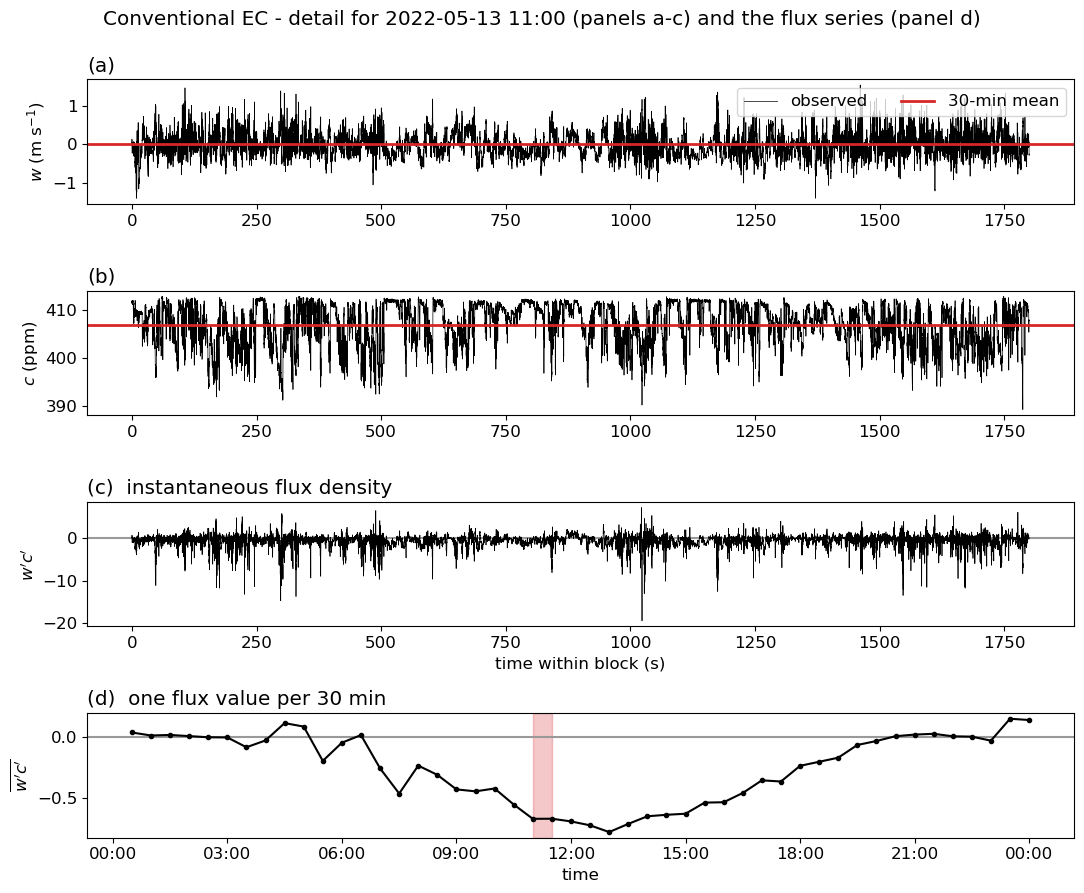

In [5]:
fig, ax = plt.subplots(4, 1, figsize=(11, 9))
fig.suptitle(f"Conventional EC - detail for {DETAIL_BLOCK:%Y-%m-%d %H:%M} "
             f"(panels a-c) and the flux series (panel d)", y=0.99)
ts = (det["TIMESTAMP_ns"] - det["TIMESTAMP_ns"].iloc[0]).dt.total_seconds()

ax[0].plot(ts, det["w"], "k", lw=0.5, label="observed")
ax[0].axhline(det["w"].mean(), color="C3", lw=2, label="30-min mean")
ax[0].set_ylabel(r"$w$ (m s$^{-1}$)"); ax[0].legend(loc="upper right", ncol=2)
ax[0].set_title("(a)", loc="left")

ax[1].plot(ts, det["co2"], "k", lw=0.5)
ax[1].axhline(det["co2"].mean(), color="C3", lw=2)
ax[1].set_ylabel(r"$c$ (ppm)"); ax[1].set_title("(b)", loc="left")

ax[2].axhline(0, color="0.6")
ax[2].plot(ts, (det["w"] - det["w"].mean()) * (det["co2"] - det["co2"].mean()),
           "k", lw=0.5)
ax[2].set_ylabel(r"$w'c'$"); ax[2].set_xlabel("time within block (s)")
ax[2].set_title("(c)  instantaneous flux density", loc="left")

ax[3].axhline(0, color="0.6")
ax[3].plot(conv_flux.index, conv_flux.values, "k.-")
ax[3].axvspan(DETAIL_BLOCK, DETAIL_BLOCK + AVERAGING, color="C3", alpha=0.25)
ax[3].xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax[3].set_ylabel(r"$\overline{w'c'}$"); ax[3].set_xlabel("time")
ax[3].set_title("(d)  one flux value per 30 min", loc="left")

fig.tight_layout()
plt.show()

## 3. Wavelet eddy covariance

Instead of one mean per block, the wavelet transform splits each signal into
components at many **scales** (frequency bands) while keeping their location in
**time**. `wavelet_transform` returns an `xarray.Dataset` whose `wave` variable is
indexed by `natural_frequency` (the band frequencies, in Hz) and time.

The flux density in time-frequency is the **cross-scalogram** $\widetilde{w}\,\widetilde{c}$.
Summing it over the scales finer than the 30-minute cut-off and averaging over the
block recovers the same flux as the conventional covariance — but now we can also
see *which scales* and *which moments* produced it.

In [6]:
# decompose the detailed half-hour (w, co2, ts)
Wd = {v: wavelet_decompose(to_signal(det, v)) for v in ["w", "co2", "ts"]}

freqs = Wd["w"]["wave"].natural_frequency.values     # band frequencies [Hz], straight from the transform
turbulent = freqs >= CUTOFF_HZ                       # scales that carry turbulent flux
cross_det = Wd["w"]["wave"] * Wd["co2"]["wave"]       # cross-scalogram (flux density)

print(f"{len(freqs)} scales spanning {freqs.min():.2e}-{freqs.max():.1f} Hz; "
      f"{int(turbulent.sum())} are finer than the 30-min cut-off ({CUTOFF_HZ:.2e} Hz)")

# per-30-min wavelet flux over the whole window
# (this is exactly what the production pipeline does for each averaging period)
wave_flux = {}
for t, g in data.groupby("TIMESTAMP"):
    cw = wavelet_decompose(to_signal(g, "w"))["wave"]
    cc = wavelet_decompose(to_signal(g, "co2"))["wave"]
    cross = cw * cc
    wave_flux[t] = float(cross.where(cross.natural_frequency >= CUTOFF_HZ, drop=True)
                              .sum("natural_frequency").mean())
wave_flux = pd.Series(wave_flux, name="wavelet")
wave_flux.index = pd.to_datetime(wave_flux.index)
wave_flux.head()

18 scales spanning 7.63e-05-10.0 Hz; 15 are finer than the 30-min cut-off (5.56e-04 Hz)


2022-05-13 00:30:00    0.034630
2022-05-13 01:00:00    0.006879
2022-05-13 01:30:00    0.010729
2022-05-13 02:00:00    0.005774
2022-05-13 02:30:00    0.026884
Name: wavelet, dtype: float64

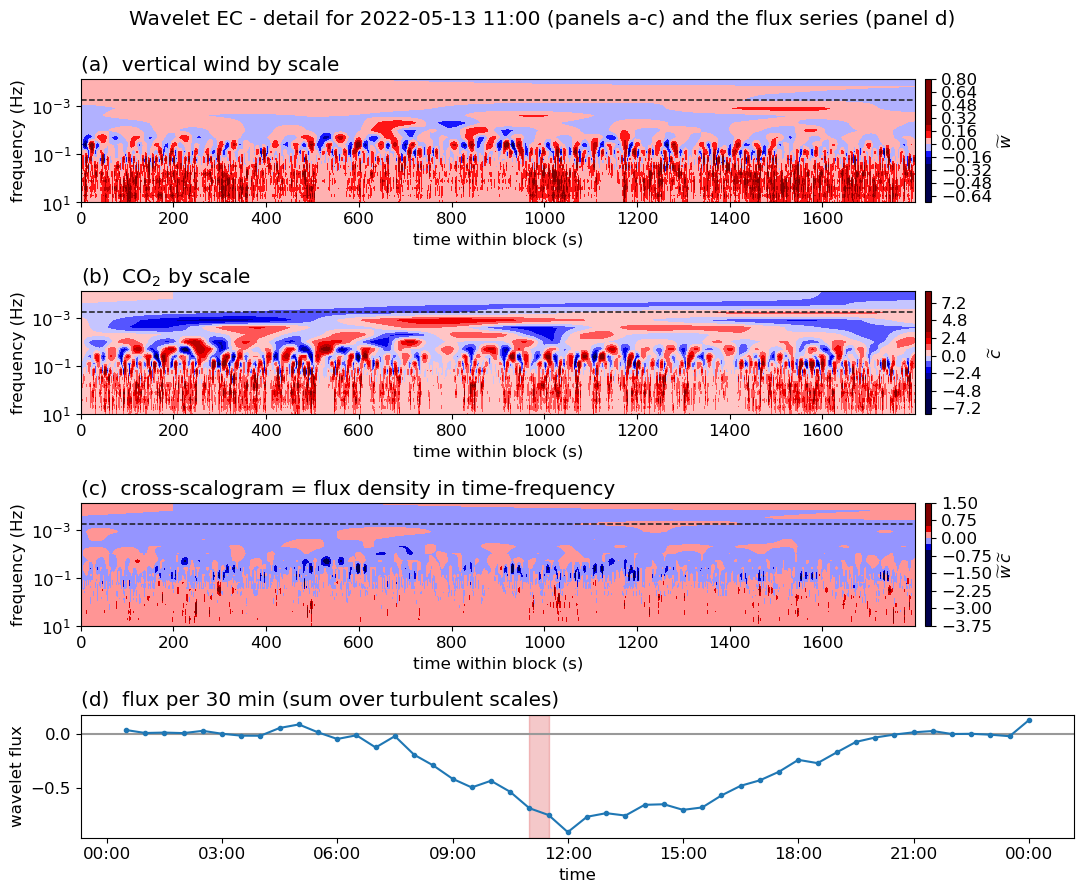

In [7]:
fig, ax = plt.subplots(4, 1, figsize=(11, 9))
fig.suptitle(f"Wavelet EC - detail for {DETAIL_BLOCK:%Y-%m-%d %H:%M} "
             f"(panels a-c) and the flux series (panel d)", y=0.99)

m = plot_scalogram(ax[0], Wd["w"]["wave"])
plt.colorbar(m, ax=ax[0], pad=0.01).set_label(r"$\widetilde{w}$")
ax[0].set_title("(a)  vertical wind by scale", loc="left")

m = plot_scalogram(ax[1], Wd["co2"]["wave"])
plt.colorbar(m, ax=ax[1], pad=0.01).set_label(r"$\widetilde{c}$")
ax[1].set_title("(b)  CO$_2$ by scale", loc="left")

m = plot_scalogram(ax[2], cross_det)
plt.colorbar(m, ax=ax[2], pad=0.01).set_label(r"$\widetilde{w}\,\widetilde{c}$")
ax[2].set_title("(c)  cross-scalogram = flux density in time-frequency", loc="left")

ax[3].axhline(0, color="0.6")
ax[3].plot(wave_flux.index, wave_flux.values, "C0.-")
ax[3].axvspan(DETAIL_BLOCK, DETAIL_BLOCK + AVERAGING, color="C3", alpha=0.25)
ax[3].xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax[3].set_ylabel("wavelet flux"); ax[3].set_xlabel("time")
ax[3].set_title("(d)  flux per 30 min (sum over turbulent scales)", loc="left")

fig.tight_layout()
plt.show()

## 4. Side by side, step by step

The same four stages, conventional (left) against wavelet (right), for the detailed
half-hour. Reading top to bottom: the **raw signal**, then how each method
**separates scales** (a single block mean vs. a full time-frequency decomposition),
then the **flux density**, and finally the **30-minute flux**. The two methods agree
on the bottom line; the wavelet column simply carries far more structure on the way
there.

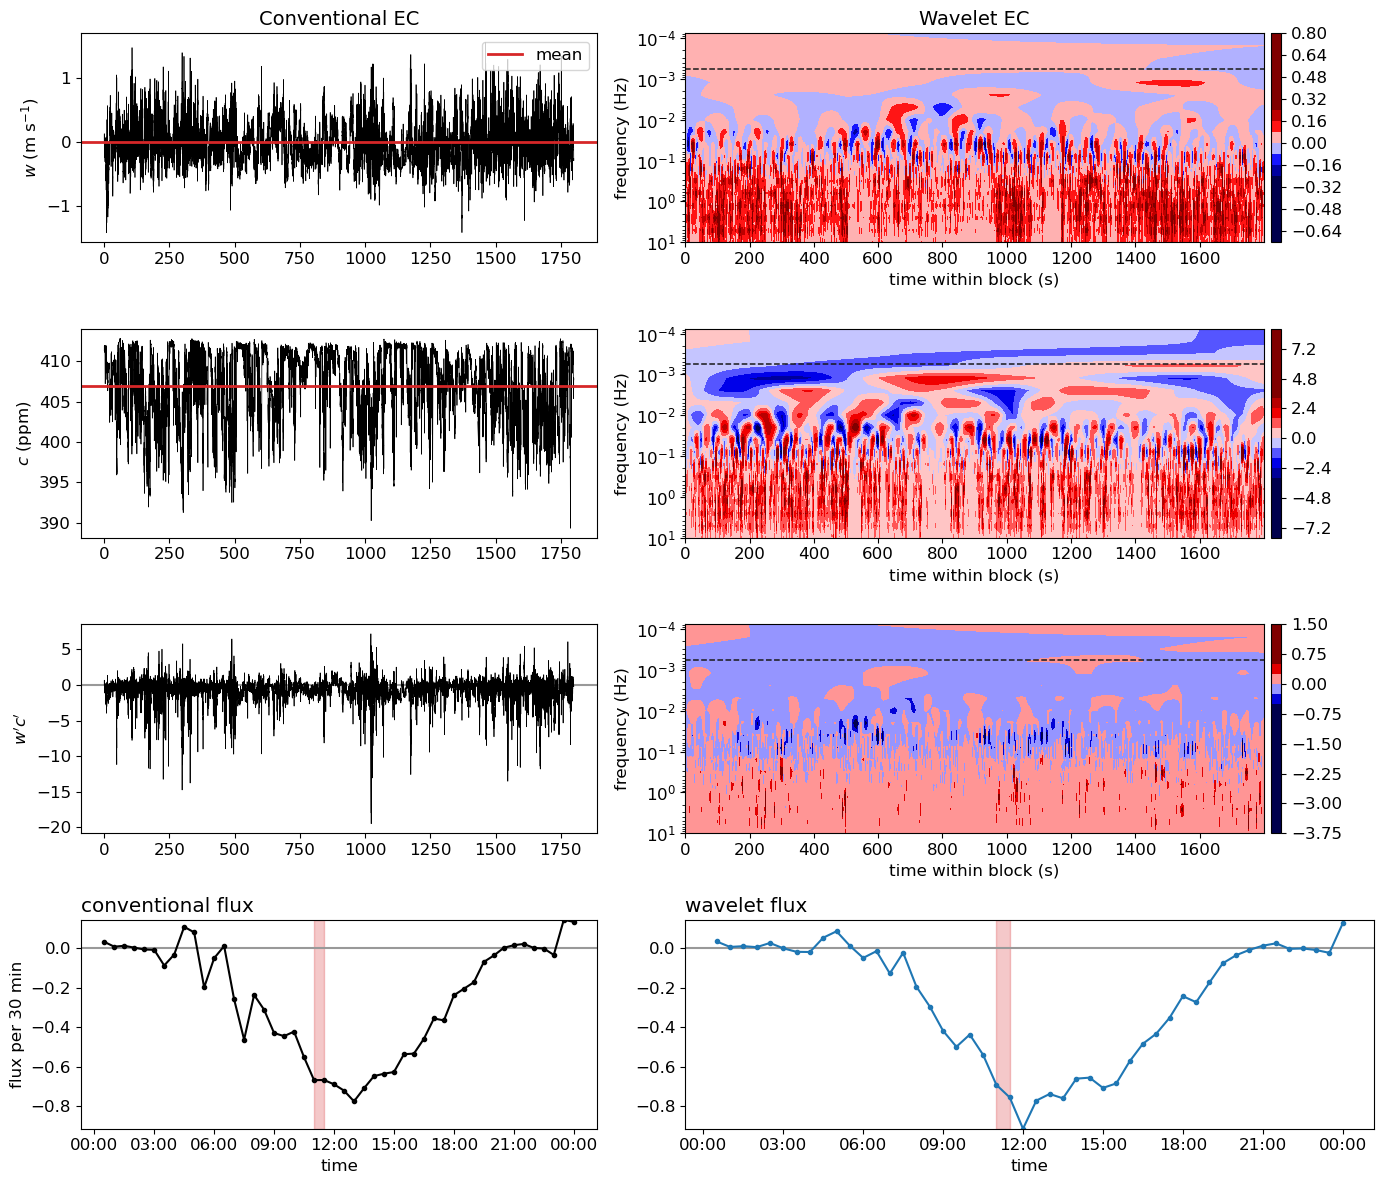

In [8]:
fig, ax = plt.subplots(4, 2, figsize=(14, 12), gridspec_kw={"width_ratios": [3, 4]})
ax[0, 0].set_title("Conventional EC", fontsize=14)
ax[0, 1].set_title("Wavelet EC", fontsize=14)
ts = (det["TIMESTAMP_ns"] - det["TIMESTAMP_ns"].iloc[0]).dt.total_seconds()

# row 0 - vertical wind
ax[0, 0].plot(ts, det["w"], "k", lw=0.5)
ax[0, 0].axhline(det["w"].mean(), color="C3", lw=2, label="mean")
ax[0, 0].set_ylabel(r"$w$ (m s$^{-1}$)"); ax[0, 0].legend(loc="upper right")
plt.colorbar(plot_scalogram(ax[0, 1], Wd["w"]["wave"]), ax=ax[0, 1], pad=0.01)

# row 1 - CO2
ax[1, 0].plot(ts, det["co2"], "k", lw=0.5)
ax[1, 0].axhline(det["co2"].mean(), color="C3", lw=2)
ax[1, 0].set_ylabel(r"$c$ (ppm)")
plt.colorbar(plot_scalogram(ax[1, 1], Wd["co2"]["wave"]), ax=ax[1, 1], pad=0.01)

# row 2 - flux density
ax[2, 0].axhline(0, color="0.6")
ax[2, 0].plot(ts, (det["w"] - det["w"].mean()) * (det["co2"] - det["co2"].mean()),
              "k", lw=0.5)
ax[2, 0].set_ylabel(r"$w'c'$")
plt.colorbar(plot_scalogram(ax[2, 1], cross_det), ax=ax[2, 1], pad=0.01)

# row 3 - flux per 30 min (shared y-limits)
for col, (series, color, lbl) in enumerate([(conv_flux, "k", "conventional"),
                                             (wave_flux, "C0", "wavelet")]):
    ax[3, col].axhline(0, color="0.6")
    ax[3, col].plot(series.index, series.values, color=color, marker=".")
    ax[3, col].axvspan(DETAIL_BLOCK, DETAIL_BLOCK + AVERAGING, color="C3", alpha=0.25)
    ax[3, col].xaxis.set_major_formatter(DateFormatter("%H:%M"))
    ax[3, col].set_xlabel("time"); ax[3, col].set_title(f"{lbl} flux", loc="left")
ylim = (min(conv_flux.min(), wave_flux.min()), max(conv_flux.max(), wave_flux.max()))
ax[3, 0].set_ylim(ylim); ax[3, 1].set_ylim(ylim)
ax[3, 0].set_ylabel("flux per 30 min")

fig.tight_layout()
plt.show()

## 5. What the wavelet view adds

Three things the single covariance number cannot give you.

**(a) A cospectrum** — how much flux comes from each scale. Time-averaging the
cross-scalogram gives the wavelet cospectrum; weighting by frequency (`f.Co`) makes
equal areas on the log axis equal contributions. Integrating it over the turbulent
scales returns the block's wavelet flux (and approximates the conventional covariance).

integral over turbulent scales = -0.6918  (block covariance = -0.6681)


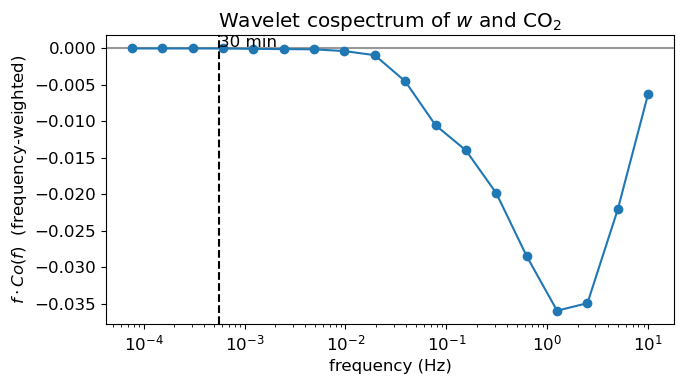

In [9]:
cosp = cross_det.mean("TIMESTAMP_ns")              # time-averaged cross-scalogram
f = cosp.natural_frequency.values

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, color="0.6")
ax.plot(f, f * cosp.values, "o-")
ax.axvline(CUTOFF_HZ, ls="--", color="k")
ax.annotate("30 min", xy=(CUTOFF_HZ, ax.get_ylim()[1]), ha="left", va="top")
ax.set_xscale("log")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel(r"$f \cdot Co(f)$  (frequency-weighted)")
ax.set_title("Wavelet cospectrum of $w$ and CO$_2$")
turb_integral = float(cosp.where(cosp.natural_frequency >= CUTOFF_HZ, drop=True).sum())
print(f"integral over turbulent scales = {turb_integral:.4f}  "
      f"(block covariance = {np.cov(det['w'], det['co2'])[0, 1]:.4f})")
fig.tight_layout()
plt.show()

**(b) Sensitivity to high-frequency loss (attenuation).** Real sensors and tube
sampling damp the highest frequencies. Discarding the fine scales one cut-off at a
time shows how much flux that costs — the wavelet decomposition makes the loss
explicit instead of hidden inside one number.

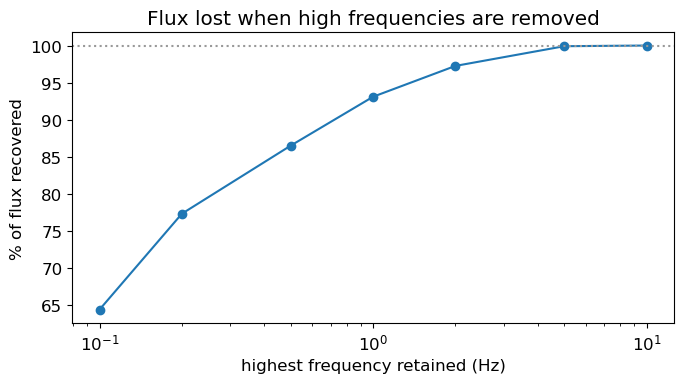

In [10]:
caps = np.array([10, 5, 2, 1, 0.5, 0.2, 0.1])
nf = cross_det.natural_frequency

def block_flux(keep_mask):
    return float(cross_det.where(keep_mask, drop=True).sum("natural_frequency").mean())

full = block_flux(nf >= CUTOFF_HZ)
recovered = [block_flux((nf <= c) & (nf >= CUTOFF_HZ)) for c in caps]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(caps, 100 * np.array(recovered) / full, "o-")
ax.axhline(100, color="0.6", ls=":")
ax.set_xscale("log")
ax.set_xlabel("highest frequency retained (Hz)")
ax.set_ylabel("% of flux recovered")
ax.set_title("Flux lost when high frequencies are removed")
fig.tight_layout()
plt.show()

**(b.2) The attenuation made visible.** Damping the highest frequencies can be visually seen in a signal.

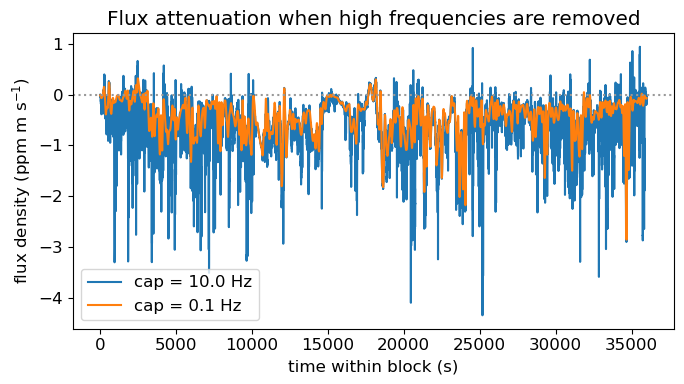

In [26]:
caps = np.array([10, 0.1])
nf = cross_det.natural_frequency

def block_flux(keep_mask):
    return cross_det.where(keep_mask, drop=True).sum("natural_frequency")

full = block_flux(nf >= CUTOFF_HZ)
recovered = [block_flux((nf <= c) & (nf >= CUTOFF_HZ)) for c in caps]

fig, ax = plt.subplots(figsize=(7, 4))
for c, r in zip(caps, recovered):
    ax.plot(r, "-", label=f"cap = {c} Hz")
ax.axhline(0, color="0.6", ls=":")
ax.legend()
ax.set_xlabel("time within block (s)")
ax.set_ylabel("flux density (ppm m s$^{-1}$)")
ax.set_title("Flux attenuation when high frequencies are removed")
fig.tight_layout()
plt.show()

**(c) The bottom lines agree.** Across every 30-min block in the window, the wavelet
flux matches the conventional covariance — so nothing above changes the headline
number; it only adds time- and scale-resolution.

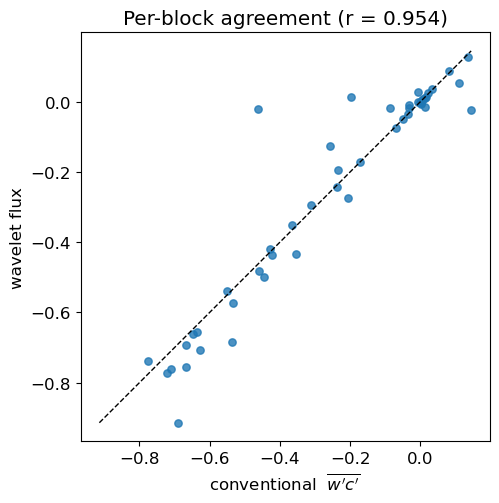

In [11]:
flux = pd.concat([conv_flux, wave_flux], axis=1).dropna()
lims = [flux.min().min(), flux.max().max()]

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot(lims, lims, "k--", lw=1)
ax.scatter(flux["conventional"], flux["wavelet"], s=28, alpha=0.8)
ax.set_xlabel(r"conventional  $\overline{w'c'}$")
ax.set_ylabel("wavelet flux")
ax.set_title(f"Per-block agreement (r = {flux['conventional'].corr(flux['wavelet']):.3f})")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

## 6. Whole-dataset fluxes: the production pipeline

The loop above is the manual version of what `waveletec` runs for you. In practice
you point it at the EddyPro setup and let it process every averaging period, writing
the cospectra/fluxes under `output/wavelet_flux/`. It is left commented so the
notebook stays light; uncomment to run the full sample.

In [12]:
# wEC.run_from_eddypro(
#     "input/EP/FR-Gri_sample.eddypro",
#     input_path="output/eddypro_raw_datasets/level_6",
#     output_folderpath="output/wavelet_flux",
# )

# load the per-period results back into one dataset, e.g.:
# fluxes = wEC.open_files_in_folder("output/wavelet_flux")
# fluxes

## Summary

| | Conventional EC | Wavelet EC |
|---|---|---|
| Separation of scales | one block mean ($\overline{x}$) | full time-frequency decomposition |
| Flux estimate | covariance over the block | sum of the cross-scalogram over turbulent scales |
| Time resolution | one value per 30 min | resolved within the block |
| Stationarity | assumed within the block | not required |
| Extra diagnostics | — | cospectrum, per-scale attenuation, time localisation |
| 30-min total | reference | agrees with conventional |

**API notes (current `waveletec`):**

- `wavelet_transform(signal, "dwt", ...)` returns an `xarray.Dataset`
  (`signal`, `wave`, `approximation`, `coi`); `wave` is indexed by
  `natural_frequency`, which holds the band frequencies **in Hz directly** — use it
  as the frequency axis (no `j2sj` conversion needed).
- The 30-minute cut-off is simply `natural_frequency >= 1/1800 Hz`.
- Pass a **writable** array to the transform (see `to_signal`); a read-only
  `to_xarray()` view raises inside PyWavelets.